# 02 EDA - Column Analysis

Quick Facts: 

- 7853 unique firms
- year range 2005 - 2018 (14 years total)
- majority of unique firms has data for either 1 year or 14 years in singular year comparison 


In [7]:
# this file is used to find the project root and set the working directory to it.
from pathlib import Path
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt




In [8]:
def find_project_root(marker=".project-root"):
    path = Path.cwd().resolve()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker}")

PROJECT_ROOT = find_project_root()
print(f"Project root found at: {PROJECT_ROOT}")

cwd = PROJECT_ROOT



Project root found at: /Users/ducjeremyvu/mime/sem-1/files/bank-fintech/essay


The data contains a substantial amount of columns and each row contains information on one firm for a given year with information about their employment and ai employment. Given the research question, these might be relevant for analyzing how AI firms differ from non-AI firms. the dataset further supplies information on various typical financial metrics 

In [9]:
data = pd.read_pickle(cwd / "data/babina_cleaned_enriched.pkl")

data.head(5)

,gvkey,year,aiempl,totalempl,act,ap,apalch,aqc,at,bast,...,market_cap,revenue_growth,log_revenue_growth,employment_growth,roa,ni_over_totalempl,log_totalempl,log_aiemplratio,log_market_cap,log_roa
0,1004,2005,0,2966,3266.840875,7756.154996,92.382724,346.670083,35461.428699,635.792844,...,12019.887343,NaN,NaN,NaN,0.030742,0.367550,7.994970,NaN,9.394318,-3.482127
1,1004,2006,0,3114,3378.999124,11550.307905,251.545487,675.031237,46728.073482,242.038056,...,61466.940358,4.669002,1.540945,0.049899,0.014052,0.210868,8.043663,NaN,11.026255,-4.264959
2,1004,2007,0,3270,7580.053949,4166.983737,-151.618807,292.996338,11305.276918,497.471787,...,24608.312812,-0.688486,NaN,0.050096,0.054889,0.189767,8.092545,NaN,10.110840,-2.902436
3,1004,2008,0,3400,2207.212657,4858.573233,339.960925,384.281240,17258.461654,1368.641043,...,33234.642495,2.114447,0.748793,0.039755,0.090258,0.458151,8.131531,NaN,10.411348,-2.405084
4,1004,2009,0,3426,1901.076198,7980.818275,284.612243,317.639772,24502.587917,1442.751281,...,69004.111391,-0.149051,NaN,0.007647,0.071095,0.508466,8.139149,NaN,11.141921,-2.643741


# Overall Dataset

## Firms and years


In [10]:
min_year, max_year = data['year'].min(), data['year'].max()
print(f'The dataset contains data from {min_year} to {max_year}')

n_firms = data['gvkey'].unique().shape[0]
print(f'The number of unique firms in the dataset is {n_firms}')



The dataset contains data from 2005 to 2018
The number of unique firms in the dataset is 7853


can see that dataset is imbalanced, initial guess is to treat groups differently. a lot of firms only providing 1 year of data while another majority providign 14 years of data. in between its mixed, containing 2 - 13 years. 

are 1200 firms with 14 years data enoguh ? 
how do we separate them ? 

for growth dynamics, data with firms ranging several years are necessary thus we can drop the ones with few years of data (e.g., < 5 years) 

firms with less then 14 years but more than 5 years could serve as a control group for robustness.  



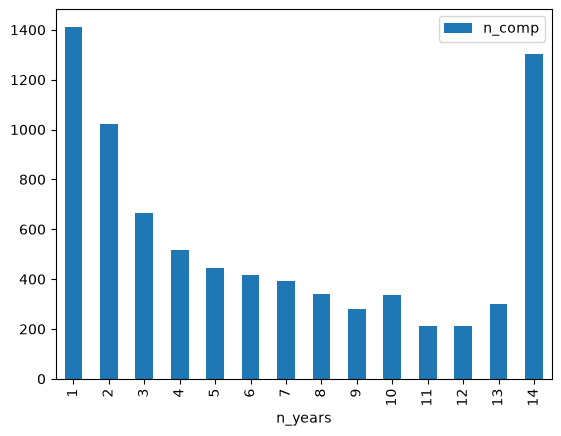

In [11]:
# first we compute how many years each firm has data for
firm_n_years = data.groupby('gvkey').agg(
    n_years = ('year', 'count')
).reset_index()

# then given above dataset, we count how many firms have data for 1 year, 2 years, etc.
firm_n_years.groupby('n_years').agg(
    n_comp = ('gvkey', 'count')
).plot(kind='bar')

plt.show()

## Count of Firms Adopting AI and in what intensity by year

we can see that over the years, more firms started employing at least one employee related to AI 
we can see that over the years the intensity also increased as in all intensities of AI employment, the number of years increased over the years

In [12]:
counts = (
    data.groupby("year")["aiemp_gt_0"]
        .value_counts()
        .unstack(fill_value=0)
)

print(counts)

aiemp_gt_0  False  True 
year                    
2005         3164    704
2006         3035    782
2007         2882    862
2008         2681    913
2009         2535    959
2010         2627   1056
2011         2650   1146
2012         2561   1265
2013         2397   1378
2014         2223   1485
2015         2019   1567
2016         1867   1586
2017         1714   1585
2018         1430   1549


In [13]:
counts = (
    data.groupby("year")["ai_intensity"]
        .value_counts()
        .unstack(fill_value=0)
)

print(counts)

ai_intensity  High AI  Low AI  No AI
year                                
2005               72     632   3164
2006               89     693   3035
2007               84     778   2882
2008               72     841   2681
2009               84     875   2535
2010              105     951   2627
2011              127    1019   2650
2012              160    1105   2561
2013              213    1165   2397
2014              275    1210   2223
2015              334    1233   2019
2016              362    1224   1867
2017              422    1163   1714
2018              441    1108   1430


# Firm size - employment and ai employment


takeaways: 

    employment:

    - firms who are able to employ ai on average greater in size 
    - reason might be greater resources for that but needs to be cross checked with other metrics like revenue and operational profit because firm size is just one side of the picture 

    ai employment ratio 

    - ai employment ratio log mean increases over time as well as the number of ai firms. 
    - log variance remain quite similar and stablize over the years 
    - that means we can see a general increase in ai employment over total employment 
    - we see that while in the earlier years, light low ai intensity was presents but firms slowly adoped greater ai intensity in employment 



## AI Adoption 

the following shows a histogram over the years for the log_aiemplratio covariate, which mainly is a log proxy for the share of ai employment ratio 

here in the summary statistics we can see that indeed there is a gradual shift in means indicating a growing trend in ai employment relative to total employment.

we formally test it and see that the changes over the years are significant. 

including the intensity grouping, supports our findings, showing that over the years more firms adopted higher intensity in ai employment. 

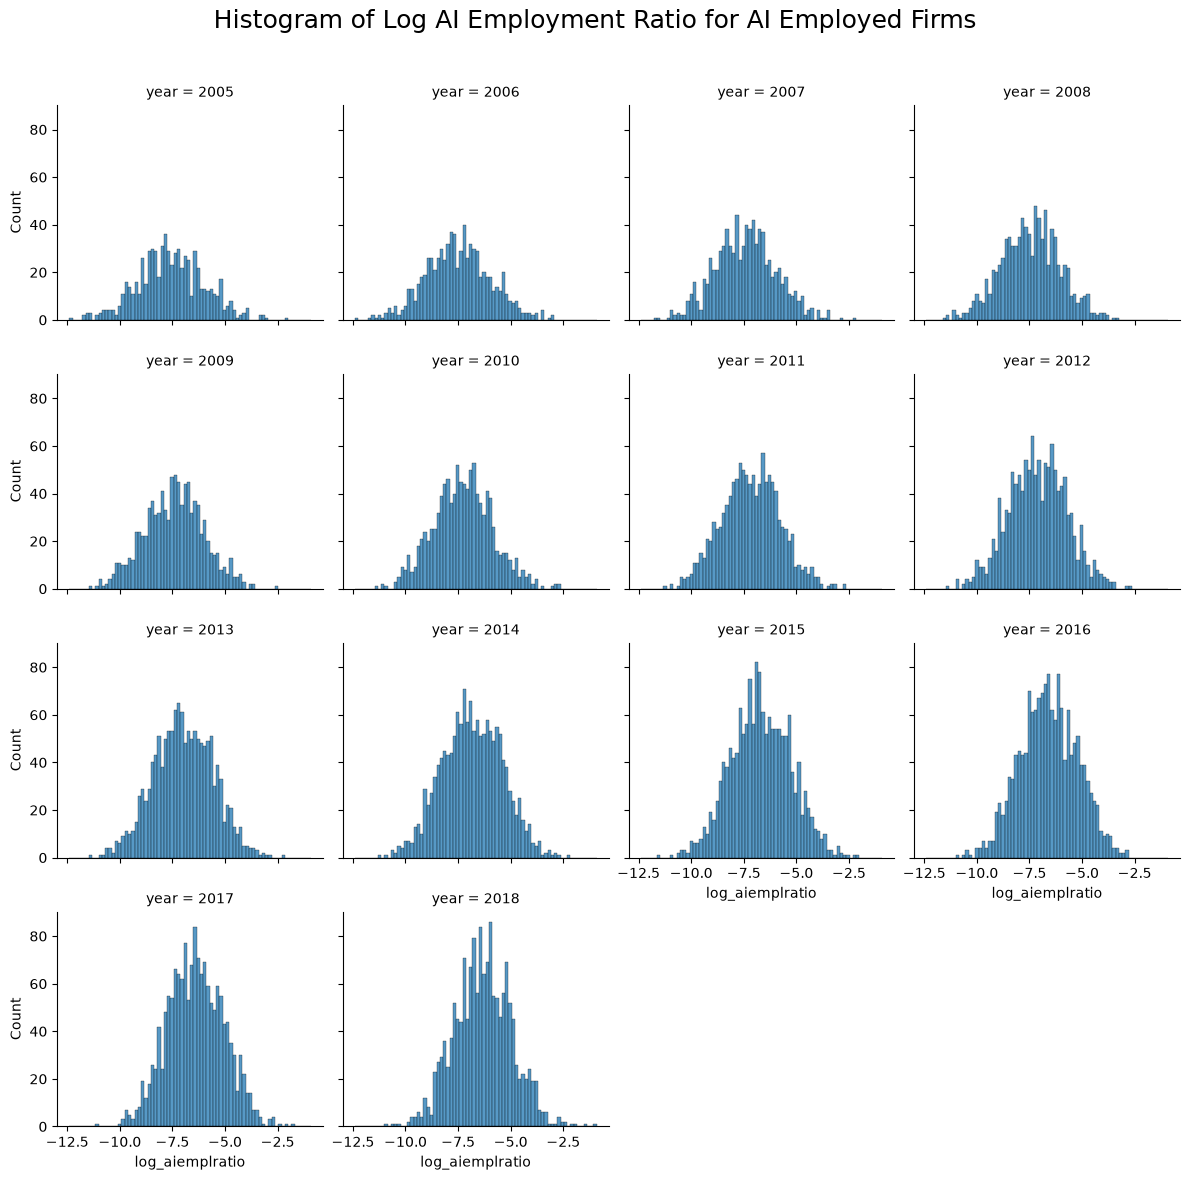

In [14]:
g = sns.displot(
    data=data[data['aiemp_gt_0']], 
    x='log_aiemplratio', 
    col="year",
    col_wrap=4,
    height=3,
    kind="hist"

)

g.figure.suptitle("Histogram of Log AI Employment Ratio for AI Employed Firms", fontsize=18)
g.figure.subplots_adjust(top=0.9)

plt.show()

In [15]:
summary = (
    data[data['aiemp_gt_0']]
    .groupby("year")["log_aiemplratio"]
    .agg(
        mean="mean",
        variance="var",
        std="std",
        median="median",
        n="count"
    )
)

print(summary)

          mean  variance       std    median     n
year                                              
2005 -7.563326  2.461776  1.569005 -7.640081   704
2006 -7.484059  2.360727  1.536466 -7.521270   782
2007 -7.411531  2.116666  1.454877 -7.378128   862
2008 -7.447754  1.965856  1.402090 -7.436617   913
2009 -7.418549  1.974916  1.405317 -7.393878   959
2010 -7.266177  1.958377  1.399420 -7.271008  1056
2011 -7.174024  1.925388  1.387583 -7.173958  1146
2012 -7.108911  1.941513  1.393382 -7.121252  1265
2013 -6.980263  2.010015  1.417750 -7.023091  1378
2014 -6.837858  2.051811  1.432414 -6.840547  1485
2015 -6.694744  2.038958  1.427921 -6.725034  1567
2016 -6.585853  1.857364  1.362851 -6.606987  1586
2017 -6.400343  1.796634  1.340386 -6.413459  1585
2018 -6.320457  1.828865  1.352355 -6.331776  1549


### Formal Testing of difference in means over the years 

the following cell performs an ols regression over years additionaly fitting incorporating groups 
- can see formally that the yearly change is significant, indicating that over the years log_aiemplratio increased which in turn tells us that the adoption of ai by increasing the share of ai employees gradually increased over the years 

In [16]:
import statsmodels.formula.api as smf

model = smf.ols(
    "log_aiemplratio ~ year",
    data=data[data['aiemp_gt_0']]
).fit(
    cov_type="cluster",
    cov_kwds={"groups": data.loc[data["aiemp_gt_0"], "gvkey"]}
)

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        log_aiemplratio   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     517.0
Date:                Sat, 27 Jun 2026   Prob (F-statistic):          9.73e-105
Time:                        00:33:38   Log-Likelihood:                -29692.
No. Observations:               16837   AIC:                         5.939e+04
Df Residuals:                   16835   BIC:                         5.940e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -212.8957      9.065    -23.486      0.0

### AI Intensity Distribution over years

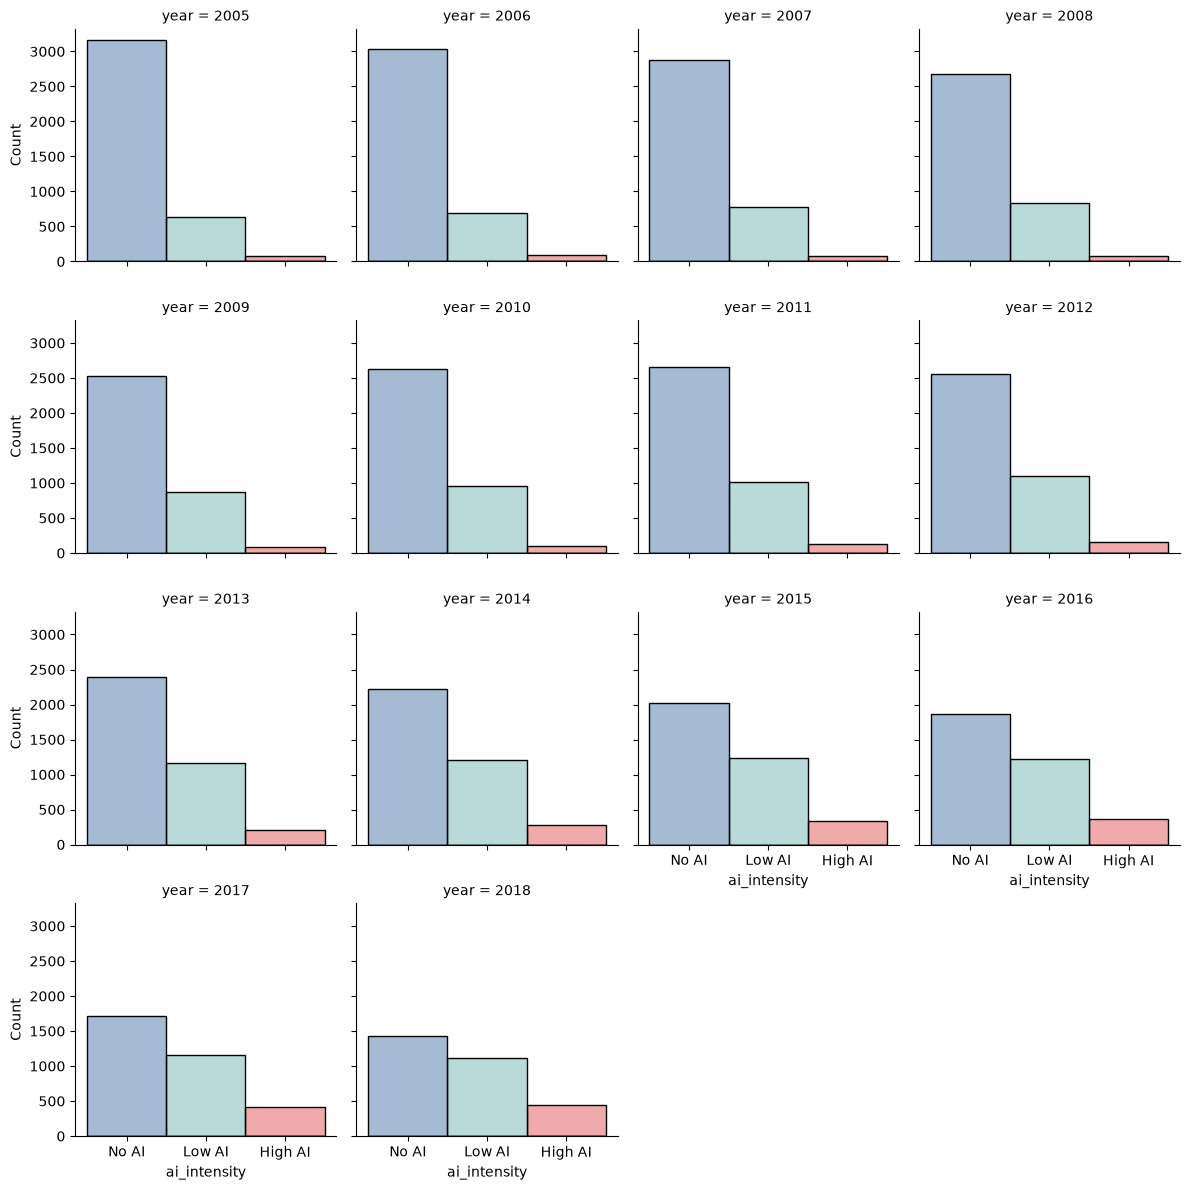

In [18]:
palette_ai_intensity = {
    "No AI": "#4C78A8",    # steel blue
    "Low AI": "#72B7B2",   # teal
    "Mid AI": "#F2CF5B",   # golden yellow
    "High AI": "#E45756",  # red
}

def plot_ai_distribution(x = 'ai_intensity'):
    g = sns.displot(
        data,     
        x = x, 
        kind="hist",
        col='year',
        col_wrap=4,
        height=3,
        palette=palette_ai_intensity,
        legend=False,
        hue=x,
    )

    return g 


plot_ai_distribution(x = 'ai_intensity')
plt.show()





## Employment in General

box plots below show that firms size is generally bigger on average for firms that employ ai specific employees
one reason could be that firms of bigger size have more resources to invest in ai technology and training 

we formally test for the simple classification that the differences in means are significant when it comes to employment. 

In [174]:
palette = {
    0: "steelblue",
    1: "tomato",
    2: "gold",
    3: "forestgreen",
    4: "mediumpurple",
}

def show_catplot(data, x, y , col, kind = 'box', palette = palette): 

    uplt = sns.catplot(
        data=data,
        x=x,
        y=y,
        col=col,
        kind=kind,
        col_wrap=4,
        height=3,
        palette=palette,
        legend=False,
        hue=x
    )
    return uplt
    # plt.show()



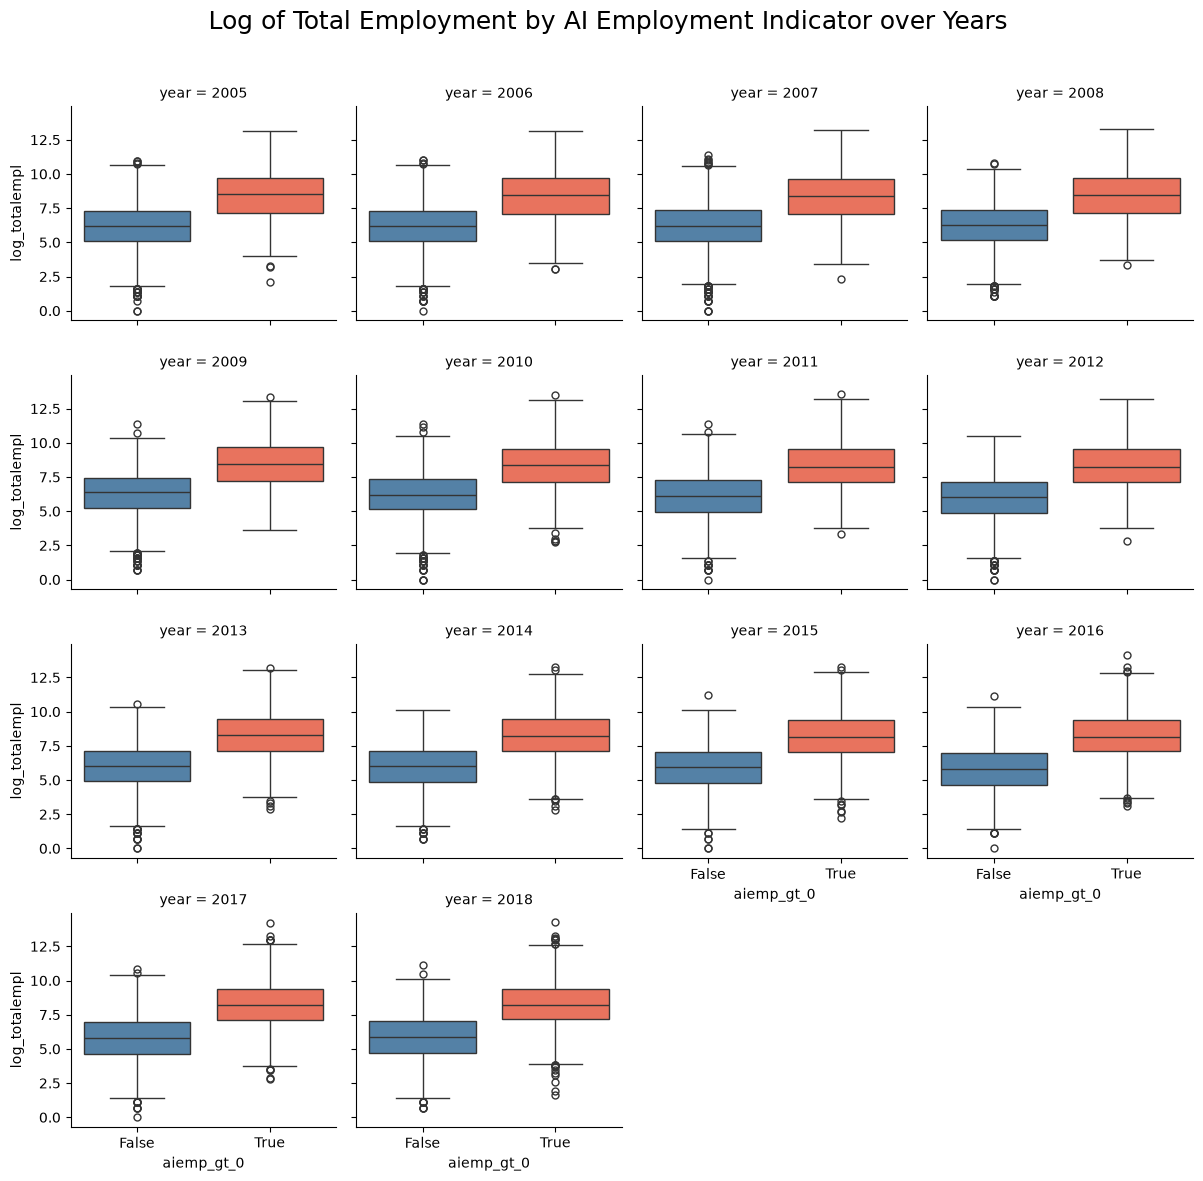

In [175]:
g = show_catplot(data, x="aiemp_gt_0", y="log_totalempl", col="year")
g.figure.suptitle("Log of Total Employment by AI Employment Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

In [176]:
data.groupby(['year','aiemp_gt_0'])['log_totalempl'].describe()

count      mean       std       min       25%       50%  \
year aiemp_gt_0                                                             
2005 False       3164.0  6.148041  1.665930  0.000000  5.075174  6.187236   
     True         704.0  8.420630  1.862374  2.079442  7.146575  8.500249   
2006 False       3035.0  6.155908  1.672444  0.000000  5.068904  6.196444   
     True         782.0  8.389493  1.852374  3.044522  7.070511  8.451267   
2007 False       2882.0  6.194652  1.652357  0.000000  5.129899  6.222574   
     True         862.0  8.373595  1.807666  2.302585  7.066018  8.403576   
2008 False       2681.0  6.228370  1.628612  1.098612  5.164786  6.289716   
     True         913.0  8.454830  1.747692  3.367296  7.178545  8.437067   
2009 False       2535.0  6.288916  1.607121  0.693147  5.257495  6.380123   
     True         959.0  8.457132  1.718352  3.610918  7.214136  8.454892   
2010 False       2627.0  6.171771  1.663425  0.000000  5.129899  6.216606   
     True        1056.0  8.366206  1.747768  2.772589  7.141829  8.344386   
2011 False       2650.0  6.089069  1.666097  0.000000  4.969813  6.119197   
     True        1146.0  8.359895  1.712692  3.367296  7.161816  8.257512   
2012 False       2561.0  6.000376  1.662082  0.000000  4.890349  6.040255   
     True        1265.0  8.338788  1.698845  2.833213  7.129298  8.255049   
2013 False       2397.0  5.974598  1.652484  0.000000  4.912655  6.018593   
     True        1378.0  8.303395  1.712895  2.890372  7.146575  8.269885   
2014 False       2223.0  5.956318  1.596609  0.693147  4.859812  6.013715   
     True        1485.0  8.276641  1.716597  2.833213  7.133296  8.246958   
2015 False       2019.0  5.867331  1.633044  0.000000  4.774904  5.934894   
     True        1567.0  8.211716  1.743058  2.197225  7.076654  8.179760   
2016 False       1867.0  5.784546  1.615513  0.000000  4.634729  5.831882   
     True        1586.0  8.247750  1.703010  3.135494  7.111920  8.181860   
2017 False       1714.0  5.781961  1.619458  0.000000  4.656330  5.800606   
     True        1585.0  8.245849  1.714271  2.772589  7.115582  8.190632   
2018 False       1430.0  5.854826  1.588388  0.693147  4.720721  5.894403   
     True        1549.0  8.235095  1.721051  1.609438  7.160069  8.192017   

                      75%        max  
year aiemp_gt_0                       
2005 False       7.305356  10.978746  
     True        9.691407  13.109244  
2006 False       7.315551  11.020005  
     True        9.677399  13.165521  
2007 False       7.338400  11.385808  
     True        9.631053  13.226705  
2008 False       7.355002  10.764604  
     True        9.706499  13.297682  
2009 False       7.397559  11.388156  
     True        9.659240  13.368969  
2010 False       7.348266  11.386205  
     True        9.562508  13.464451  
2011 False       7.269617  11.399040  
     True        9.571315  13.541858  
2012 False       7.164720  10.492329  
     True        9.573941  13.198641  
2013 False       7.152269  10.555135  
     True        9.497866  13.216657  
2014 False       7.134492  10.113911  
     True        9.465603  13.231862  
2015 False       7.071572  11.200882  
     True        9.414871  13.255334  
2016 False       6.961296  11.163878  
     True        9.407237  14.135214  
2017 False       6.968850  10.838463  
     True        9.401209  14.196238  
2018 False       7.016154  11.118712  
     True        9.353401  14.255405

### formally testing the mean using welch t test

welch t test, 
- data for each group look normal, variance also similar, 
- test result show formally there is a difference in means



West, R. M. (2021). Best practice in statistics: Use the Welch t -test when testing the difference between two groups. Annals of Clinical Biochemistry: International Journal of Laboratory Medicine, 58(4), 267–269. https://doi.org/10.1177/0004563221992088


In [177]:
from scipy.stats import ttest_ind
# REV [AI-16]

def welcht_t_test_ai_vs_non_ai(x):
    results = []

    for year, df in data.groupby("year"):

        ai = df.loc[df["aiemp_gt_0"], x]
        non_ai = df.loc[~df["aiemp_gt_0"], x]

        t, p = ttest_ind(
            ai,
            non_ai,
            equal_var=False
        )

        results.append({
            "year": year,
            "AI mean": ai.mean(),
            "Non-AI mean": non_ai.mean(),
            "Difference": ai.mean() - non_ai.mean(),
            "t": t,
            "p": p
        })

    results = pd.DataFrame(results)
    return results

welcht_t_test_ai_vs_non_ai("log_totalempl")

,year,AI mean,Non-AI mean,Difference,t,p
0,2005,8.420630,6.148041,2.272588,29.830489,3.165329e-139
1,2006,8.389493,6.155908,2.233585,30.653361,1.080719e-150
2,2007,8.373595,6.194652,2.178943,31.654957,4.122521e-164
3,2008,8.454830,6.228370,2.226460,33.816599,2.024590e-186
4,2009,8.457132,6.288916,2.168216,33.870759,7.771993e-191
5,2010,8.366206,6.171771,2.194435,34.933717,4.202446e-206
6,2011,8.359895,6.089069,2.270826,37.809774,1.425372e-239
7,2012,8.338788,6.000376,2.338412,40.340432,9.178839e-274
8,2013,8.303395,5.974598,2.328798,40.734699,5.213604e-285
9,2014,8.276641,5.956318,2.320324,41.467188,6.510266e-298


## expanding previous classification with ai intensity classification 

- it could be that on average firms with greater employment size seem to at least employ a tiny fraction with ai due to greater resources. 
- greater ai intensity according to the graphs, show a negative relationship to log total employment. it could mean that smaller firms are more likely to have higher ai intensity if their business model builds upon the adoption of ai. 

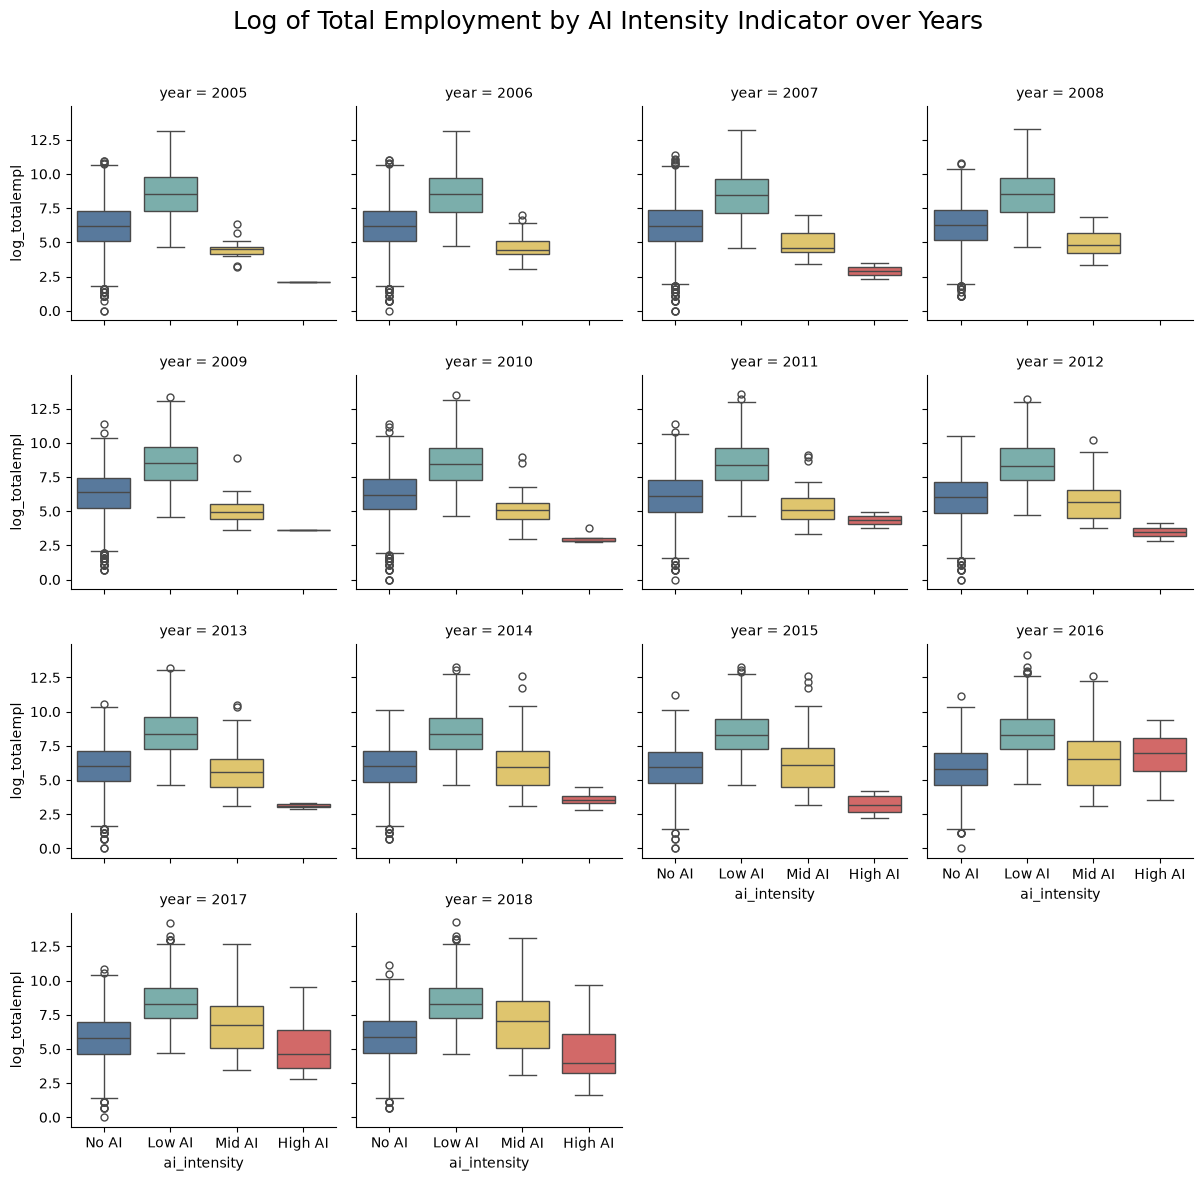

In [178]:
g = show_catplot(data, x="ai_intensity", y="log_totalempl", col="year", palette = palette_ai_intensity)
g.figure.suptitle("Log of Total Employment by AI Intensity Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

### AI Employment

# Revenue

the following shows box plots comparing revenue between ai and non ai companies. it as quite apparent, that we cant see any differences, statistical test yet to be performed. 

In [179]:
data['revt'].describe()

count    50622.000000
mean     15045.856074
std       8628.439285
min          0.808278
25%       7641.474443
50%      15017.614057
75%      22482.720326
max      29984.385316
Name: revt, dtype: float64

## Simple classification

### plot

<Axes: xlabel='revt', ylabel='Count'>

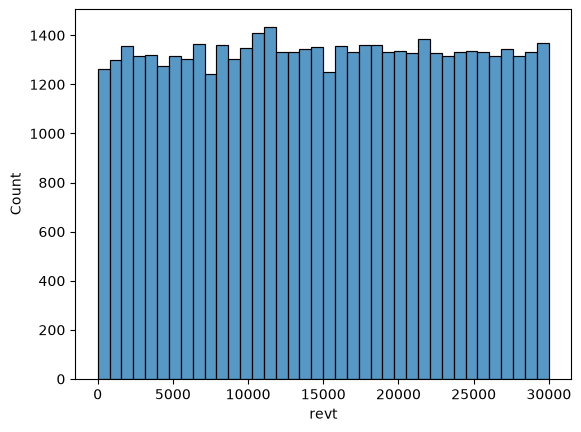

In [180]:
sns.histplot(data['revt'])

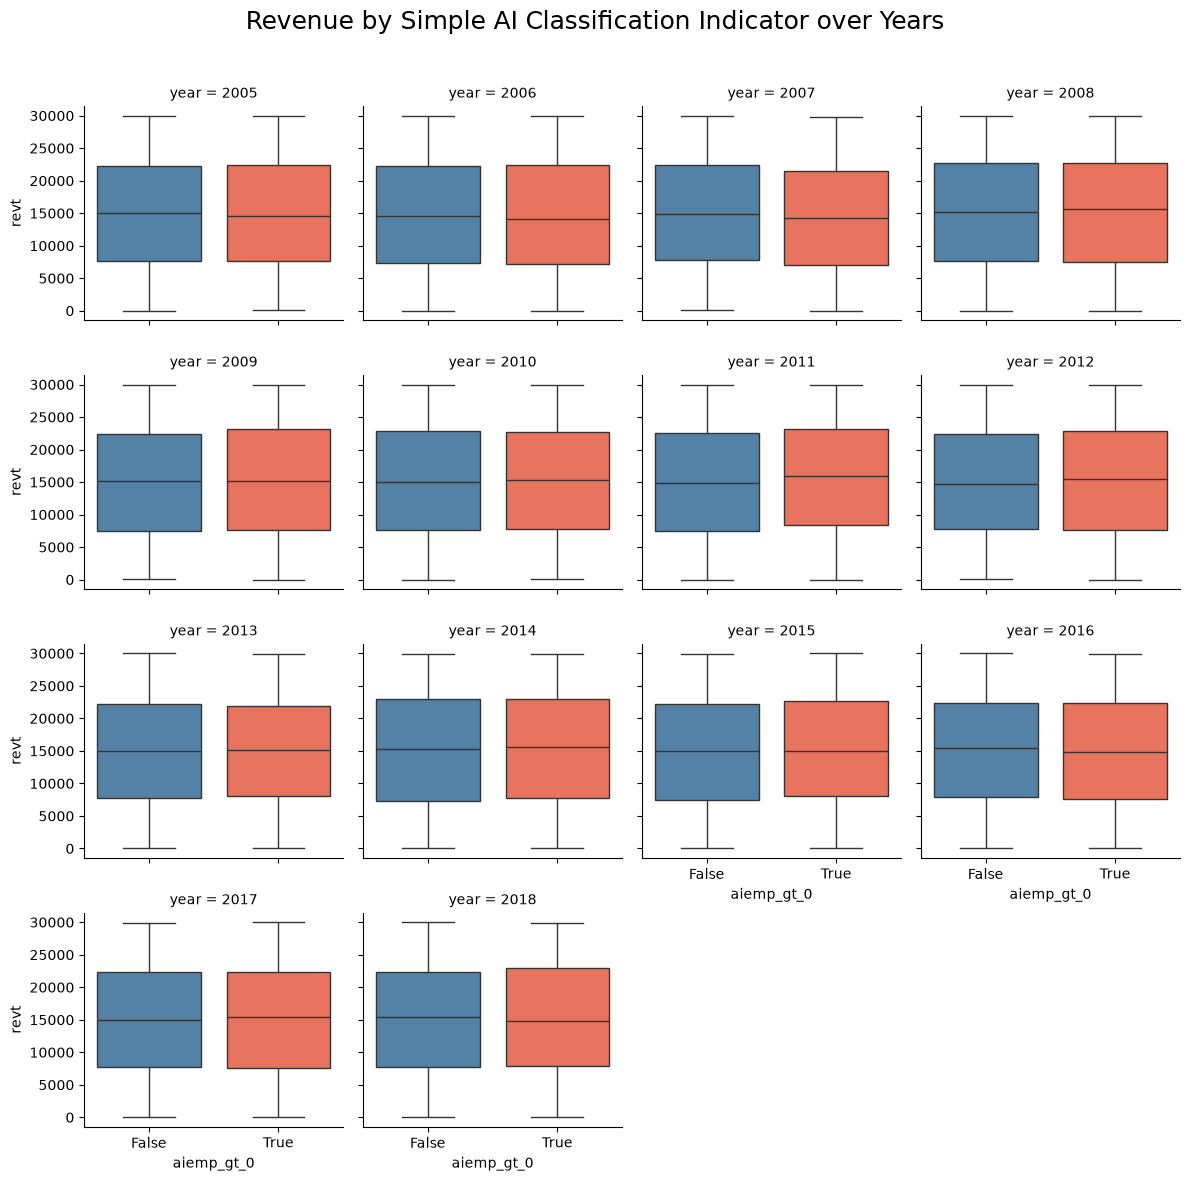

In [181]:
g = show_catplot(
    data,
    x="aiemp_gt_0",
    y="revt",
    col="year",
    kind="box"    
)

g.figure.suptitle("Revenue by Simple AI Classification Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

### Testting on difference in mean 

In [182]:
data.groupby(['year','aiemp_gt_0'])['revt'].describe()

count          mean          std        min          25%  \
year aiemp_gt_0                                                              
2005 False       3164.0  14981.191387  8612.811416   8.173319  7613.586496   
     True         704.0  14919.086703  8656.140132  74.105351  7593.880471   
2006 False       3035.0  14780.960907  8674.763565   1.503592  7351.527609   
     True         782.0  14693.397197  8795.985190   4.301426  7115.911638   
2007 False       2882.0  15074.519742  8594.593842  40.519553  7845.837681   
     True         862.0  14537.249186  8566.345601  10.912118  6999.418783   
2008 False       2681.0  15122.585248  8655.973869  20.718572  7648.559776   
     True         913.0  15207.058952  8721.280365  10.983338  7539.862042   
2009 False       2535.0  15082.216773  8686.747902  17.735881  7467.691038   
     True         959.0  15307.699318  8933.158557   0.808278  7635.936533   
2010 False       2627.0  15091.485714  8728.770431   7.797770  7647.719551   
     True        1056.0  15248.573333  8637.071807  42.665079  7834.059589   
2011 False       2650.0  14984.802660  8652.433965  13.631292  7433.286996   
     True        1146.0  15587.142348  8526.290297  10.452782  8325.684217   
2012 False       2561.0  14917.520856  8606.652747  17.523972  7732.658587   
     True        1265.0  15205.400215  8674.433995   7.666202  7638.494498   
2013 False       2397.0  15047.274422  8524.309916   3.145077  7817.226366   
     True        1378.0  14885.581325  8402.371411  77.928323  8035.391739   
2014 False       2223.0  15149.598005  8706.397479   2.383861  7323.534803   
     True        1485.0  15352.170721  8615.413061  81.837030  7736.007687   
2015 False       2019.0  14857.717284  8567.661471  23.270886  7502.060110   
     True        1567.0  15101.930177  8561.498178  16.759808  8059.915499   
2016 False       1867.0  15138.927783  8543.225357  12.025266  7978.414732   
     True        1586.0  14935.502606  8629.279488   9.458046  7556.240600   
2017 False       1714.0  15073.901204  8577.638681   5.062694  7685.053582   
     True        1585.0  15101.515068  8568.916237   1.062951  7614.159894   
2018 False       1430.0  15042.456691  8586.812118  60.445695  7696.654149   
     True        1549.0  15085.379082  8715.310900  12.279759  7824.428188   

                          50%           75%           max  
year aiemp_gt_0                                            
2005 False       15009.456580  22227.337407  29984.385316  
     True        14507.245929  22467.560355  29955.990480  
2006 False       14598.991198  22314.994162  29964.784590  
     True        14076.858028  22460.503154  29944.560734  
2007 False       14943.357459  22459.605663  29965.144444  
     True        14285.357121  21471.686138  29808.555974  
2008 False       15111.989137  22694.235791  29982.738312  
     True        15669.982137  22644.502132  29962.046181  
2009 False       15087.549693  22448.154856  29972.794979  
     True        15187.019889  23215.404479  29949.057305  
2010 False       14940.373492  22899.484699  29981.758411  
     True        15318.698707  22645.737700  29968.942058  
2011 False       14840.879635  22539.381043  29969.468463  
     True        15968.831041  23233.078998  29964.267533  
2012 False       14755.269897  22338.745185  29982.704420  
     True        15477.846357  22837.994019  29970.107634  
2013 False       14919.931622  22157.099181  29981.342855  
     True        15097.257876  21964.591986  29933.577893  
2014 False       15268.457570  22915.971118  29935.582769  
     True        15570.237799  23016.059073  29957.480488  
2015 False       14927.370078  22135.492179  29969.118502  
     True        14977.690737  22635.400545  29978.743702  
2016 False       15464.786087  22306.390525  29982.035550  
     True        14887.978352  22441.989859  29967.045561  
2017 False       14921.344140  22269.518074  29936.700663  
     True        15349.738244  22266.975444  29980.597102

In [183]:
welcht_t_test_ai_vs_non_ai("revt")

,year,AI mean,Non-AI mean,Difference,t,p
0,2005,14919.086703,14981.191387,-62.104684,-0.172328,0.863213
1,2006,14693.397197,14780.960907,-87.563710,-0.248933,0.803455
2,2007,14537.249186,15074.519742,-537.270555,-1.614359,0.106672
3,2008,15207.058952,15122.585248,84.473704,0.253257,0.800103
4,2009,15307.699318,15082.216773,225.482544,0.670829,0.502421
5,2010,15248.573333,15091.485714,157.087619,0.497636,0.618796
6,2011,15587.142348,14984.802660,602.339688,1.989244,0.046798
7,2012,15205.400215,14917.520856,287.879358,0.968205,0.333035
8,2013,14885.581325,15047.274422,-161.693098,-0.566219,0.571288
9,2014,15352.170721,15149.598005,202.572716,0.698601,0.484852


## AI Intensity case

### Plot

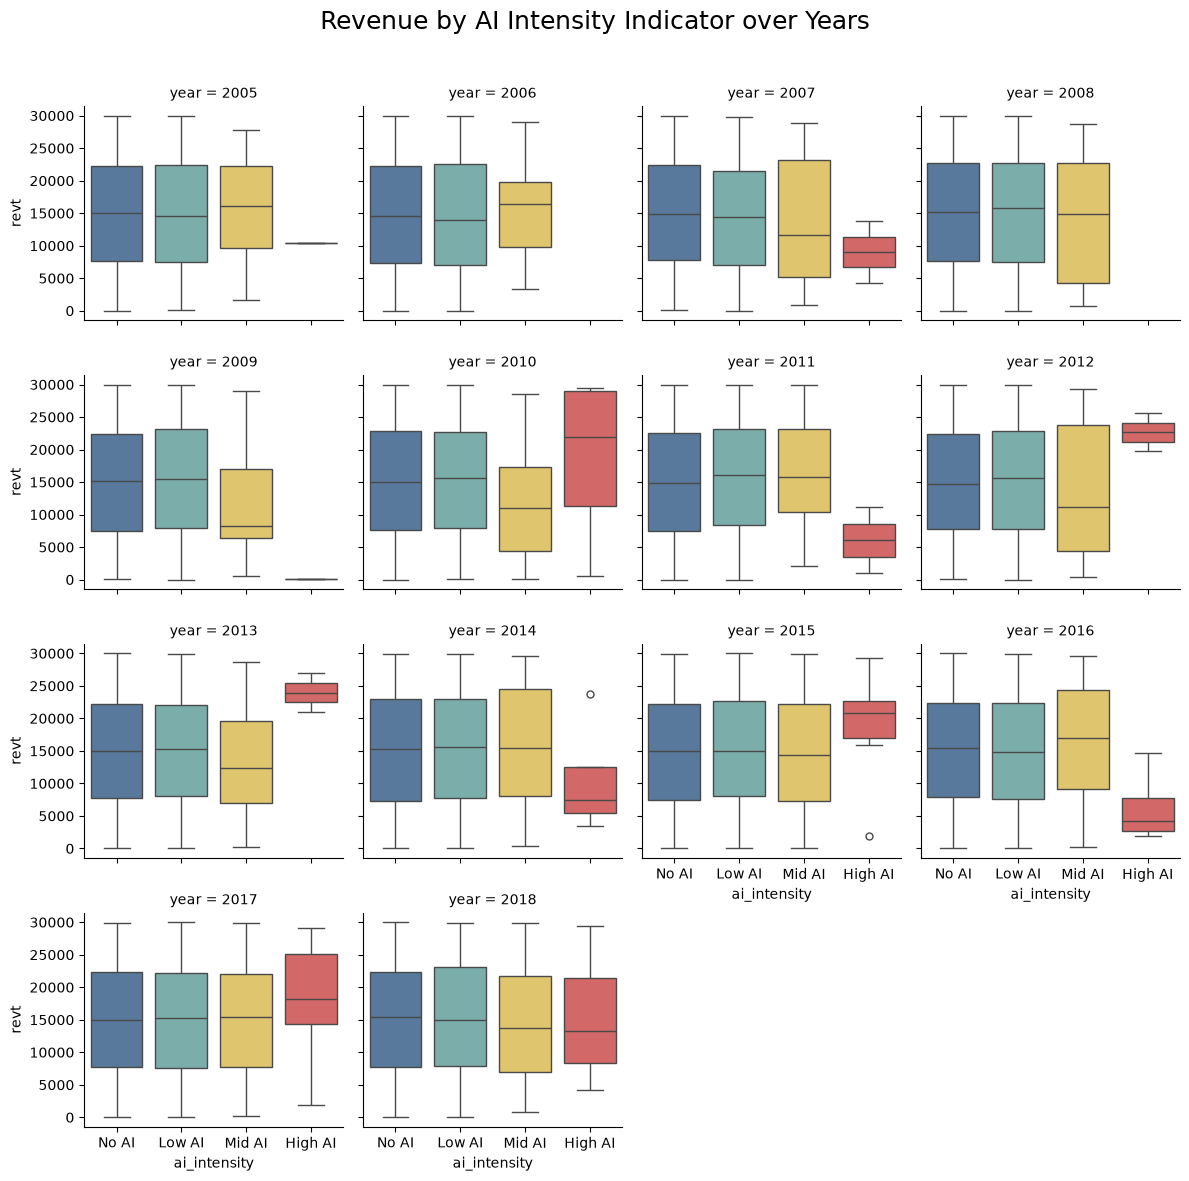

In [184]:
g = show_catplot(
    data,
    x="ai_intensity",
    y="revt",
    col="year",
    kind="box",
    palette = palette_ai_intensity
)

g.figure.suptitle("Revenue by AI Intensity Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

## Revenue Growth 
REF [AI-14]

The following showcases boxplots and line plots for both Simple Binary Classification Case and AI Intensitiy Classification. While the Binary Classification cant show any indication about the revenue growth, the AI Intensity Classification shows for high AI intensity adoption, that revenue growth might behave differently than the rest of the group classes. 

### Box Plots

#### Simple Binary Classifier

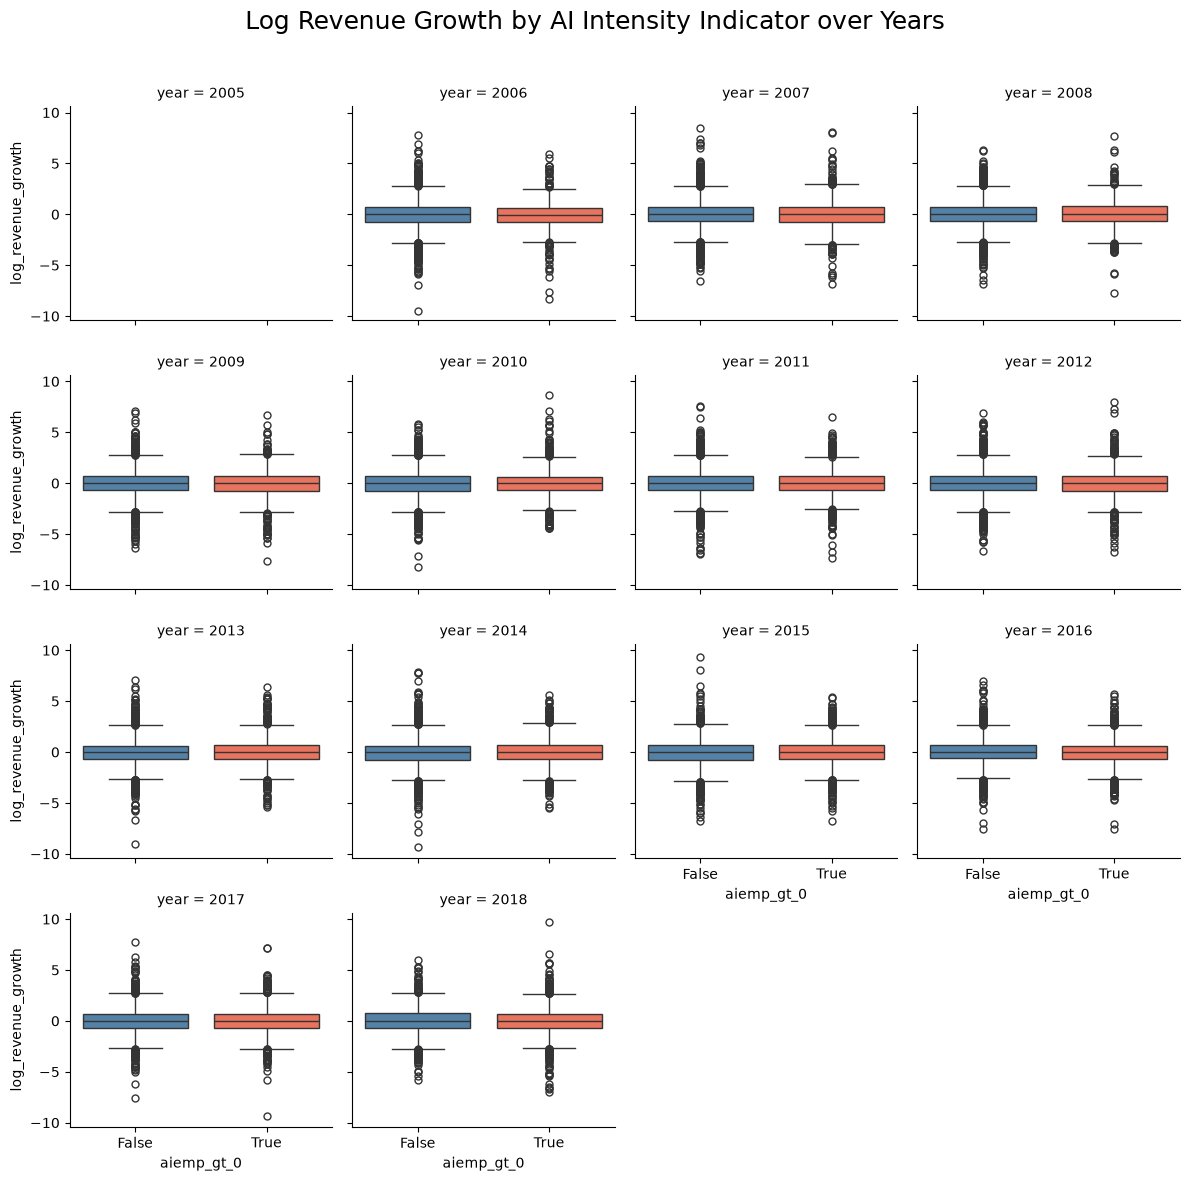

In [185]:
g = show_catplot(
    data,
    x="aiemp_gt_0",
    y="log_revenue_growth",
    col="year",
    kind="box"    
)

g.figure.suptitle("Log Revenue Growth by AI Intensity Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

#### Intensity Classifier

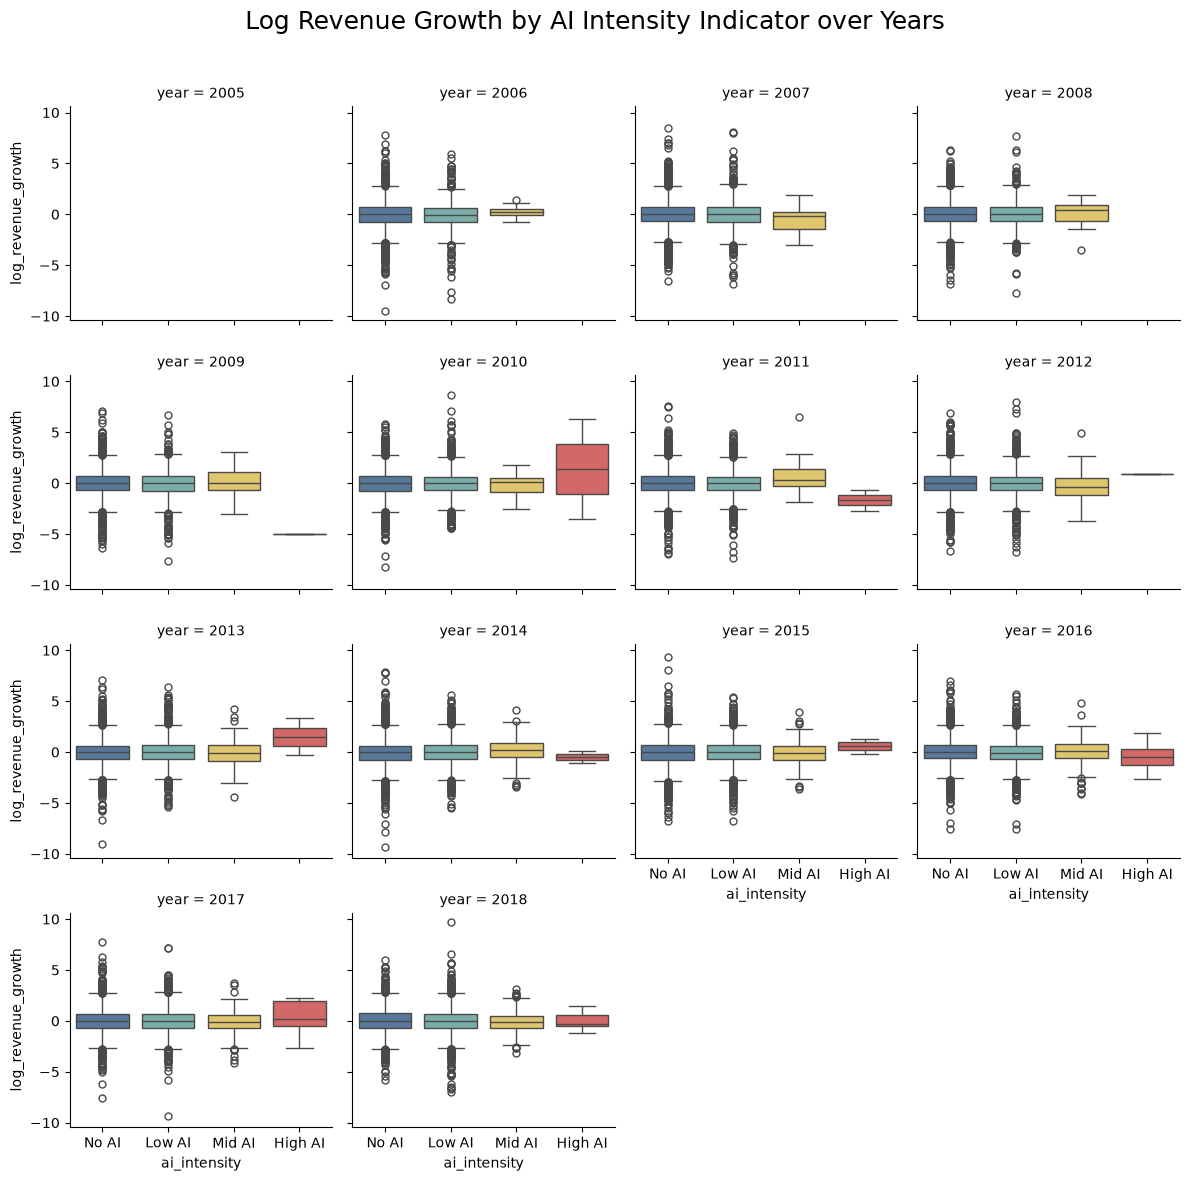

In [186]:
g = show_catplot(
    data,
    x="ai_intensity",
    y="log_revenue_growth",
    col="year",
    kind="box",
    palette = palette_ai_intensity    
)

g.figure.suptitle("Log Revenue Growth by AI Intensity Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

### Line Plots

#### Simple binary classifier

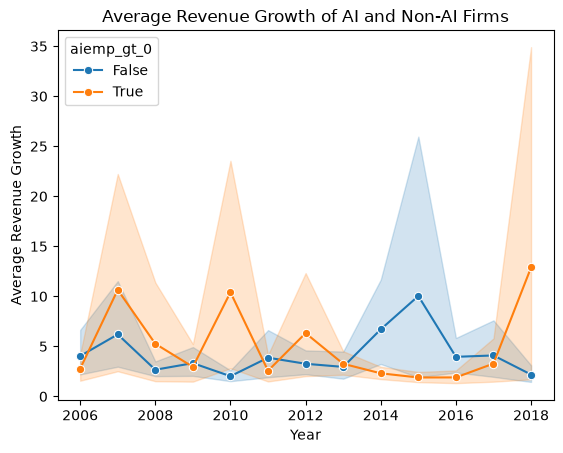

In [187]:
data_rv_growth = data.dropna(subset=["revenue_growth"])

sns.lineplot(
    data=data_rv_growth,
    x="year",
    y="revenue_growth",
    hue="aiemp_gt_0",
    marker="o"
)

plt.ylabel("Average Revenue Growth")
plt.xlabel("Year")
plt.title("Average Revenue Growth of AI and Non-AI Firms")
plt.show()

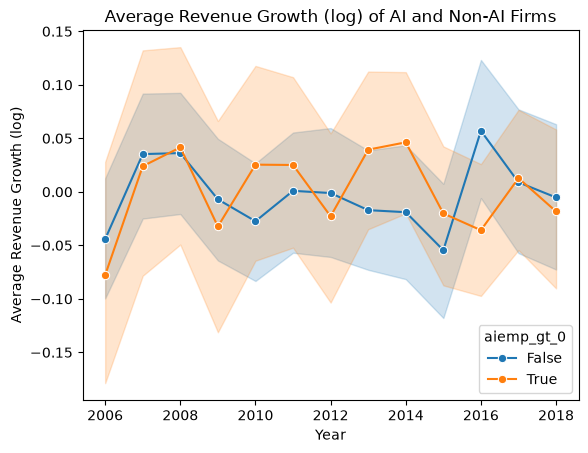

In [188]:
sns.lineplot(
    data=data_rv_growth,
    x="year",
    y="log_revenue_growth",
    hue="aiemp_gt_0",
    marker="o"
)

plt.ylabel("Average Revenue Growth (log)")
plt.xlabel("Year")
plt.title("Average Revenue Growth (log) of AI and Non-AI Firms")
plt.show()

In [189]:
data.groupby(['year','aiemp_gt_0'])['revenue_growth'].describe()

count       mean         std       min       25%       50%  \
year aiemp_gt_0                                                                
2005 False          0.0        NaN         NaN       NaN       NaN       NaN   
     True           0.0        NaN         NaN       NaN       NaN       NaN   
2006 False       2361.0   4.034343   57.942901 -0.999923 -0.514076 -0.016604   
     True         741.0   2.765912   18.966518 -0.999758 -0.522860 -0.034164   
2007 False       2477.0   6.197630  106.649755 -0.998583 -0.488297 -0.004605   
     True         843.0  10.651086  151.006248 -0.998895 -0.516638  0.009352   
2008 False       2376.0   2.663130   18.351933 -0.998882 -0.488416  0.023141   
     True         890.0   5.258440   80.465792 -0.999540 -0.491040  0.046358   
2009 False       2239.0   3.322835   35.874059 -0.998293 -0.512562 -0.000110   
     True         921.0   2.950008   28.726482 -0.999531 -0.521916 -0.004056   
2010 False       2348.0   2.018130   13.349940 -0.999732 -0.513314 -0.008481   
     True        1017.0  10.403887  182.429568 -0.988092 -0.496978 -0.019410   
2011 False       2332.0   3.868716   57.227276 -0.999002 -0.500584  0.009266   
     True        1114.0   2.564267   22.553024 -0.999344 -0.465551  0.021566   
2012 False       2266.0   3.260145   28.441732 -0.998754 -0.502066 -0.028968   
     True        1230.0   6.322298   94.964246 -0.998847 -0.519104 -0.006075   
2013 False       2161.0   2.947225   31.899990 -0.999880 -0.502075 -0.034809   
     True        1338.0   3.256721   22.641486 -0.995471 -0.496388  0.001663   
2014 False       2029.0   6.702728   99.855588 -0.999911 -0.522157 -0.007480   
     True        1452.0   2.306389   12.350590 -0.995876 -0.490137  0.011779   
2015 False       1823.0  10.035396  267.904450 -0.998910 -0.528927 -0.032622   
     True        1529.0   1.888447   10.367496 -0.998805 -0.502302 -0.019314   
2016 False       1682.0   3.953826   37.581245 -0.999496 -0.464624  0.029378   
     True        1552.0   1.895900   12.806984 -0.999492 -0.501470 -0.043521   
2017 False       1584.0   4.091880   61.835713 -0.999465 -0.493739  0.015812   
     True        1567.0   3.277114   46.753581 -0.999915 -0.499208 -0.016947   
2018 False       1357.0   2.180638   15.719610 -0.996968 -0.490438  0.027730   
     True        1540.0  12.886785  409.585744 -0.999097 -0.497278  0.001846   

                      75%           max  
year aiemp_gt_0                          
2005 False            NaN           NaN  
     True             NaN           NaN  
2006 False       0.963985   2459.531001  
     True        0.816755    357.702405  
2007 False       1.050399   4663.991214  
     True        1.102069   3188.703931  
2008 False       1.056308    564.076078  
     True        1.171716   2286.580467  
2009 False       0.986473   1184.905586  
     True        1.008049    771.625456  
2010 False       0.930436    325.945754  
     True        0.914375   5634.713509  
2011 False       0.974517   1984.581317  
     True        0.928850    685.600815  
2012 False       1.041005    988.304751  
     True        0.930794   2781.695921  
2013 False       0.898565   1182.099827  
     True        0.935476    578.293714  
2014 False       0.898923   2723.255534  
     True        1.067188    281.456189  
2015 False       0.943876  10917.568515  
     True        0.933237    212.439673  
2016 False       0.990457   1043.005188  
     True        0.898342    303.451482  
2017 False       0.993594   2330.731013  
     True        1.017180   1321.044970  
2018 False       1.075030    398.289489  
     True        0.940905  16051.910568

#### Intensity Classifier

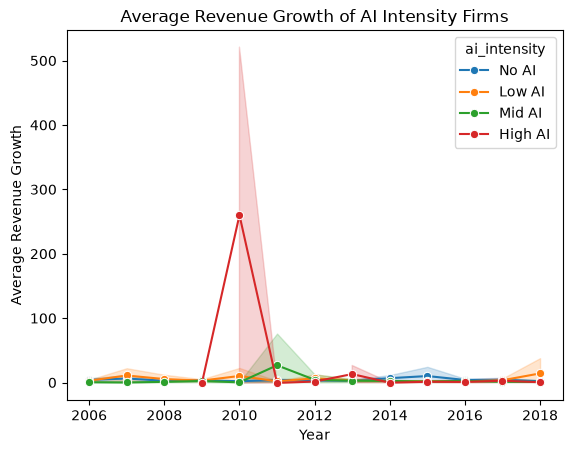

In [190]:
data_rv_growth = data.dropna(subset=["revenue_growth"])

sns.lineplot(
    data=data_rv_growth,
    x="year",
    y="revenue_growth",
    hue="ai_intensity",
    marker="o"
)

plt.ylabel("Average Revenue Growth")
plt.xlabel("Year")
plt.title("Average Revenue Growth of AI Intensity Firms")
plt.show()

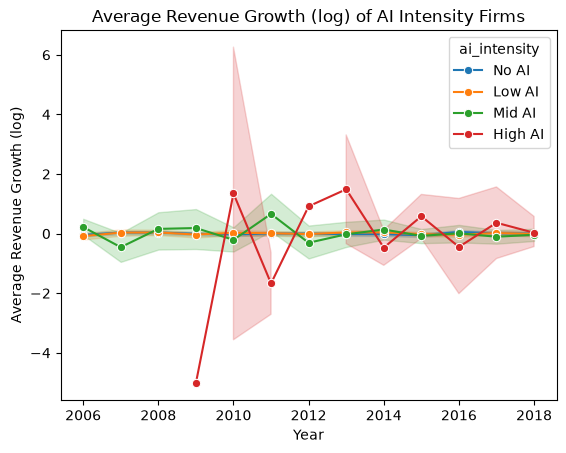

In [191]:
sns.lineplot(
    data=data_rv_growth,
    x="year",
    y="log_revenue_growth",
    hue="ai_intensity",
    marker="o"
)

plt.ylabel("Average Revenue Growth (log)")
plt.xlabel("Year")
plt.title("Average Revenue Growth (log) of AI Intensity Firms")
plt.show()

### Ratio Scatterplot

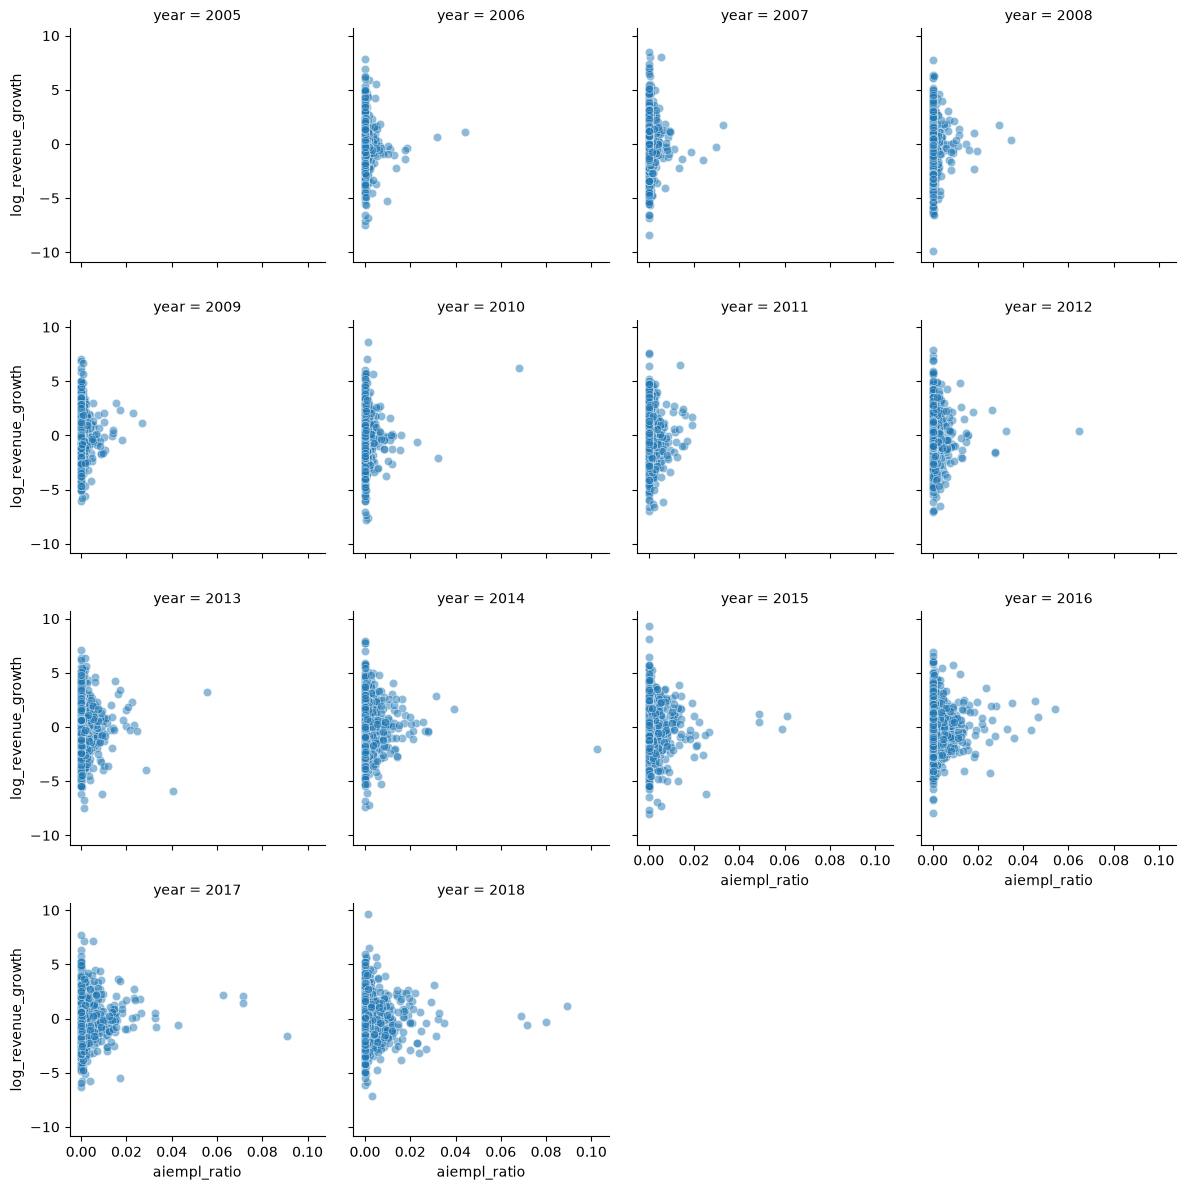

In [ ]:
sns.relplot(
    data=data,
    x="aiempl_ratio",
    y="log_revenue_growth",
    col="year",
    col_wrap=4,
    kind="scatter",
    alpha=0.5,
    height=3
)
plt.show()

# Market Cap 


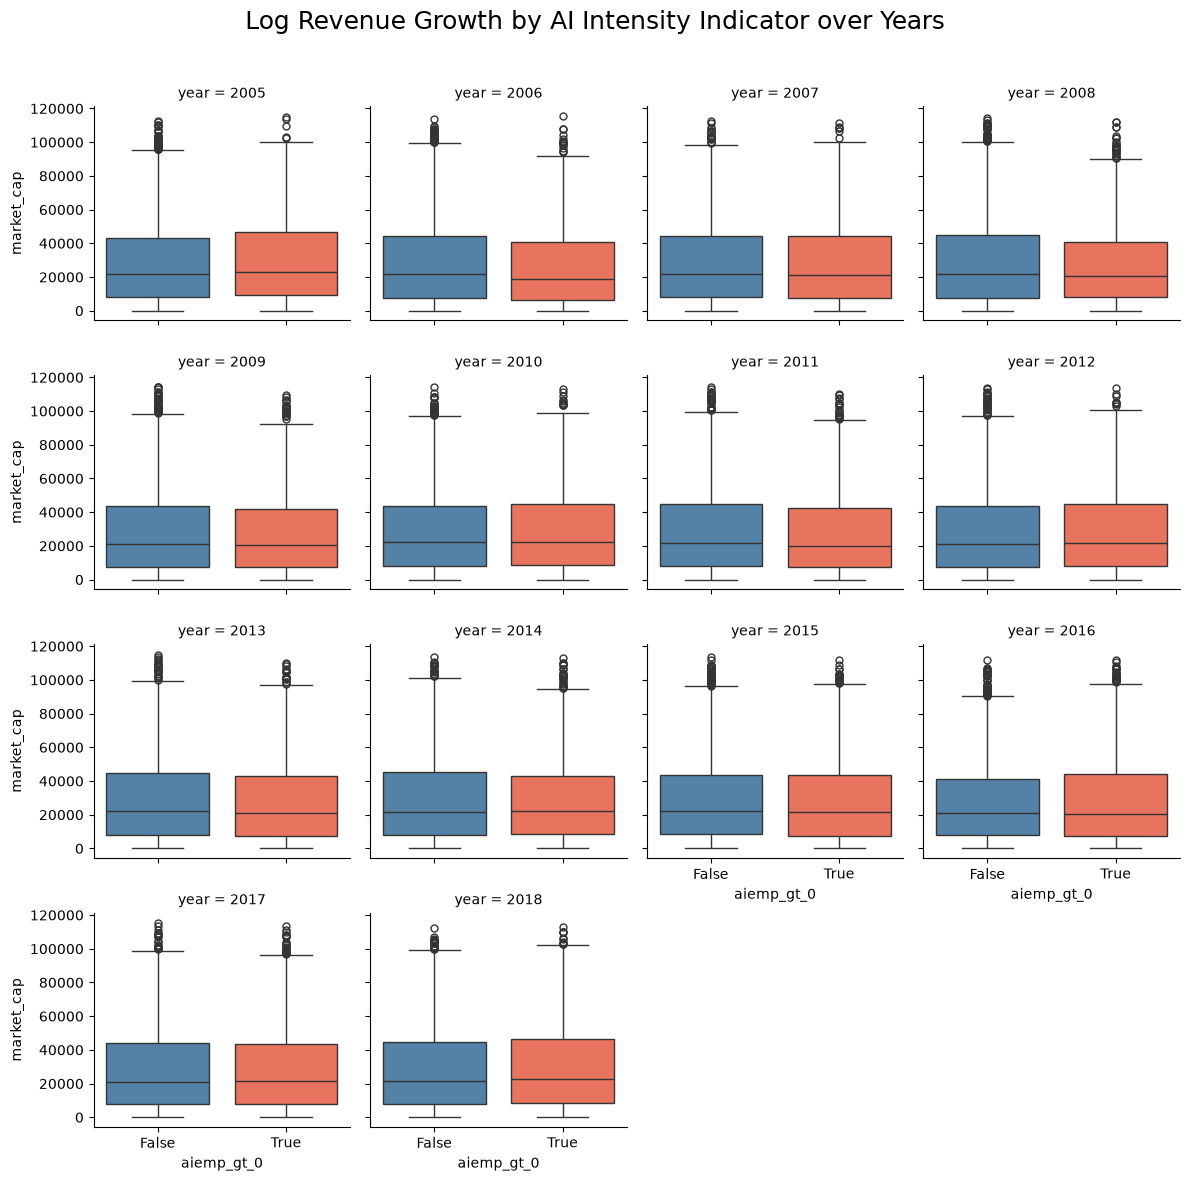

In [192]:
g = show_catplot(
    data,
    x="aiemp_gt_0",
    y="market_cap",
    col="year",
    kind="box",
    # palette = palette_ai_intensity    
)

g.figure.suptitle("Log Revenue Growth by AI Intensity Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

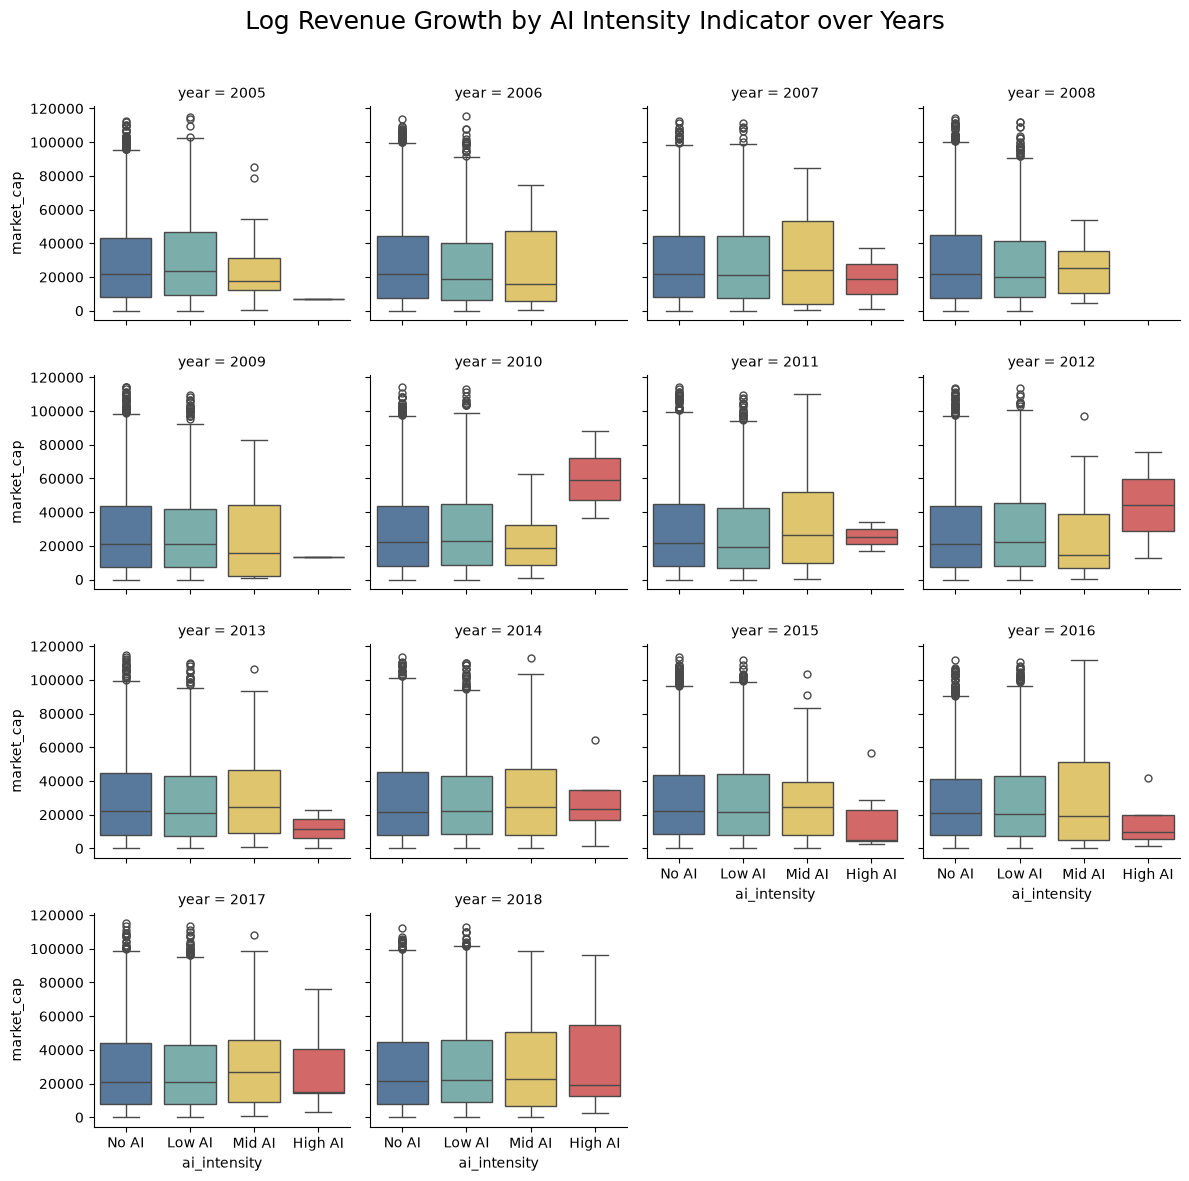

In [193]:
g = show_catplot(
    data,
    x="ai_intensity",
    y="market_cap",
    col="year",
    kind="box",
    palette = palette_ai_intensity    
)

g.figure.suptitle("Log Revenue Growth by AI Intensity Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

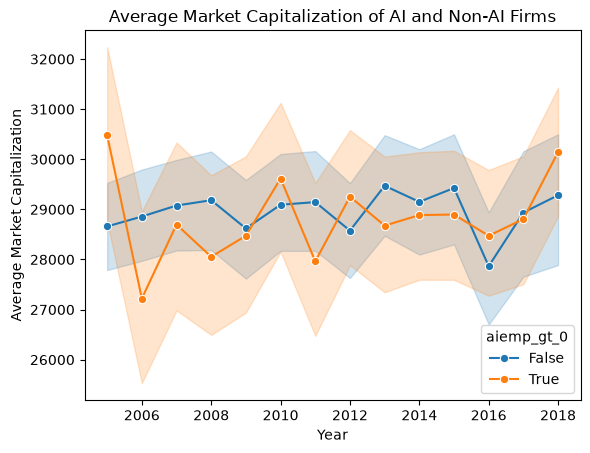

In [194]:
sns.lineplot(
    data=data,
    x="year",
    y="market_cap",
    hue="aiemp_gt_0",
    marker="o"
)

plt.ylabel("Average Market Capitalization")
plt.xlabel("Year")
plt.title("Average Market Capitalization of AI and Non-AI Firms")
plt.show()

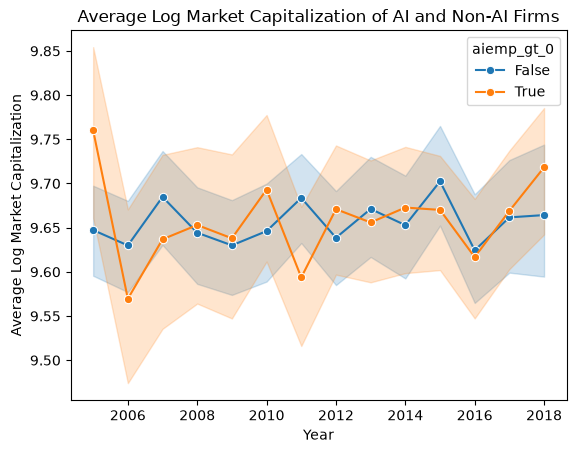

In [195]:
sns.lineplot(
    data=data,
    x="year",
    y="log_market_cap",
    hue="aiemp_gt_0",
    marker="o"
)

plt.ylabel("Average Log Market Capitalization")
plt.xlabel("Year")
plt.title("Average Log Market Capitalization of AI and Non-AI Firms")
plt.show()

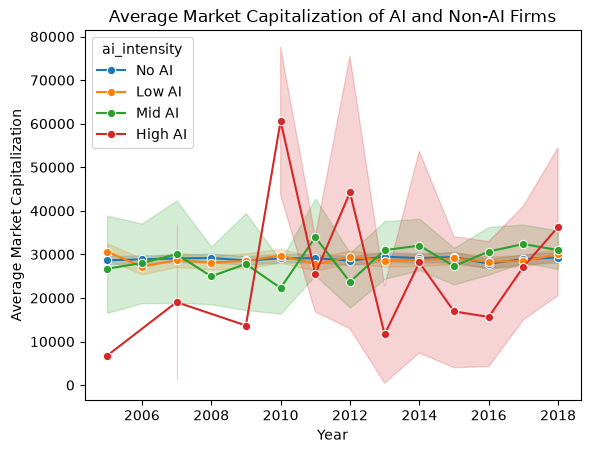

In [196]:
sns.lineplot(
    data=data,
    x="year",
    y="market_cap",
    hue="ai_intensity",
    marker="o"
)

plt.ylabel("Average Market Capitalization")
plt.xlabel("Year")
plt.title("Average Market Capitalization of AI and Non-AI Firms")
plt.show()

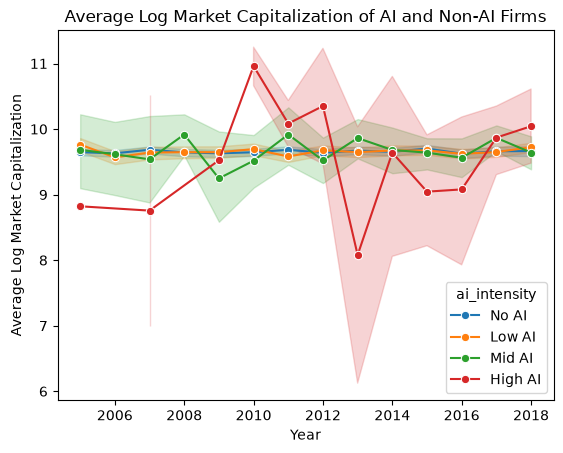

In [197]:
sns.lineplot(
    data=data,
    x="year",
    y="log_market_cap",
    hue="ai_intensity",
    marker="o"
)

plt.ylabel("Average Log Market Capitalization")
plt.xlabel("Year")
plt.title("Average Log Market Capitalization of AI and Non-AI Firms")
plt.show()

# Return on Assets

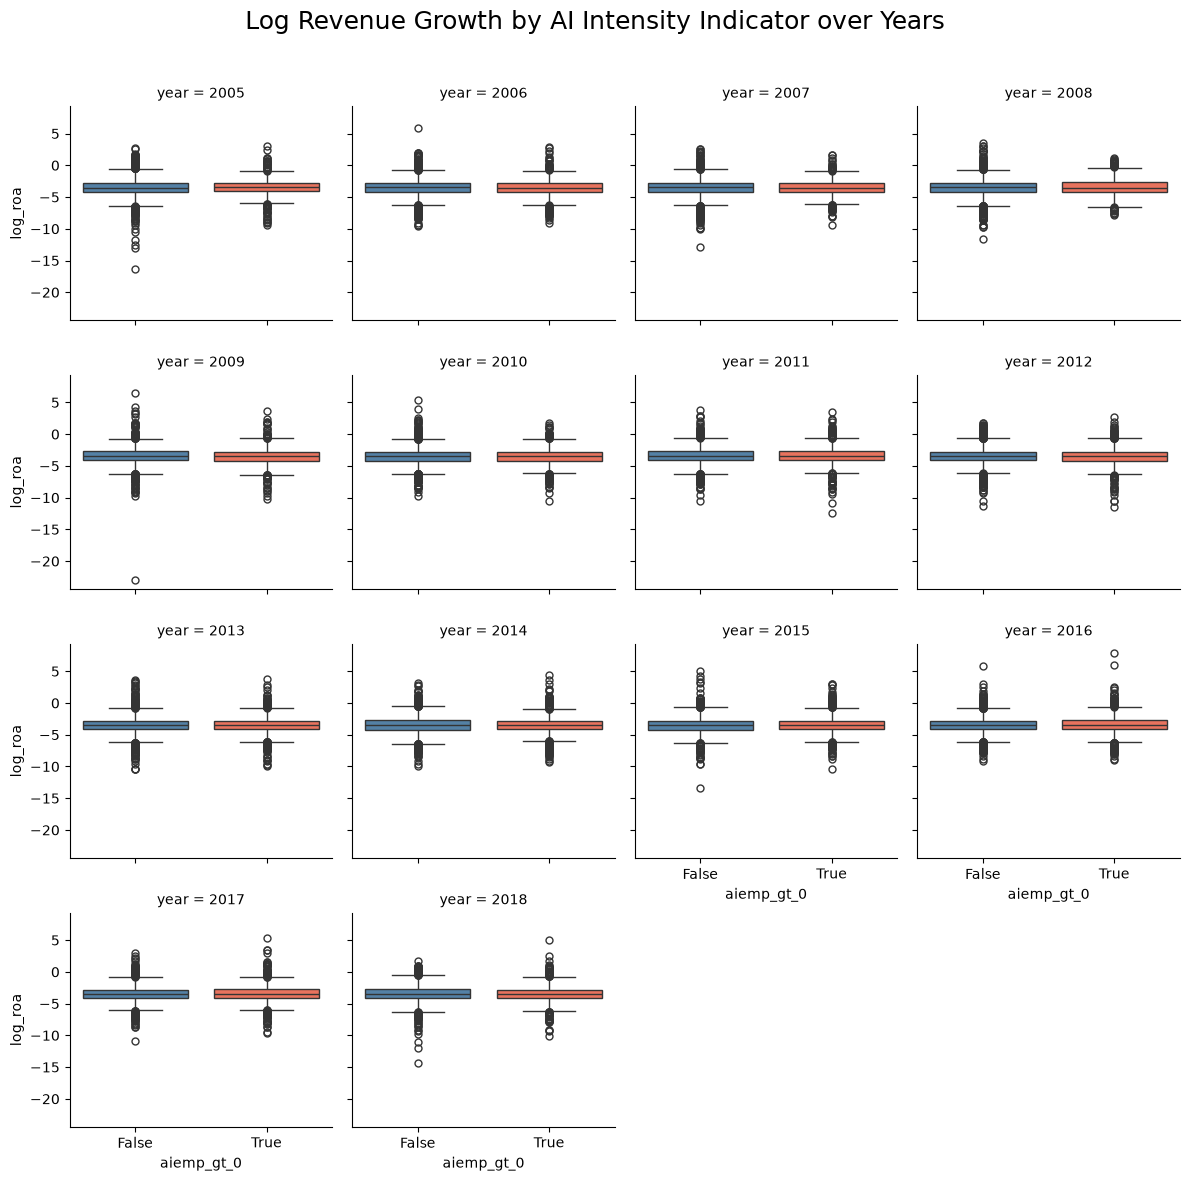

In [200]:
g = show_catplot(
    data,
    x="aiemp_gt_0",
    y="log_roa",
    col="year",
    kind="box",
    # palette = palette_ai_intensity    
)

g.figure.suptitle("Log Revenue Growth by AI Intensity Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

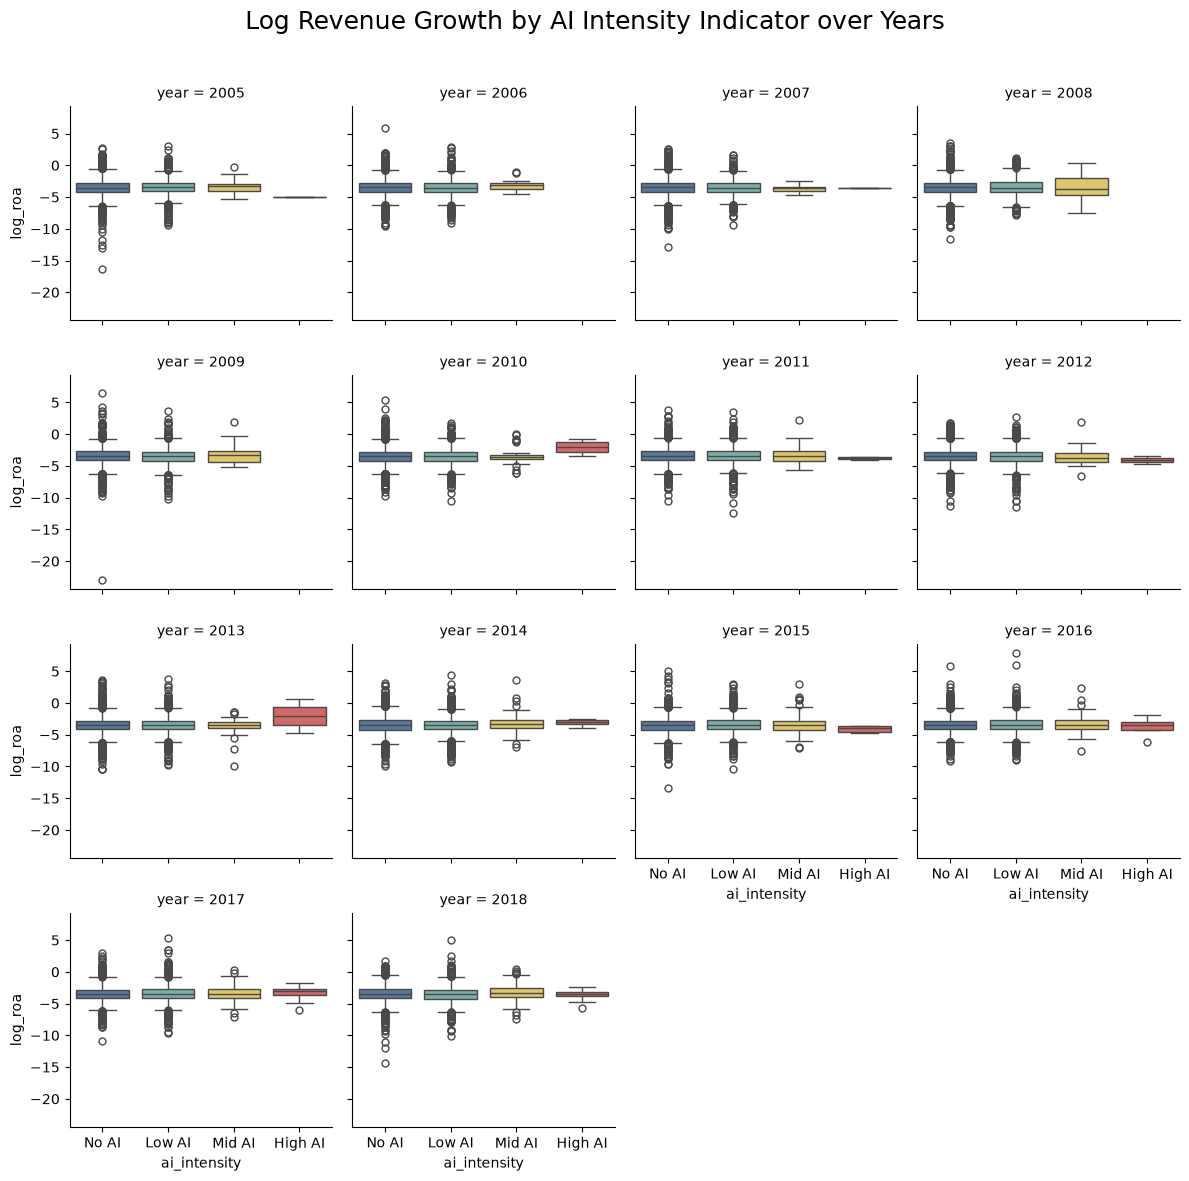

In [201]:
g = show_catplot(
    data,
    x="ai_intensity",
    y="log_roa",
    col="year",
    kind="box",
    palette = palette_ai_intensity    
)

g.figure.suptitle("Log Revenue Growth by AI Intensity Indicator over Years", fontsize=18)
g.figure.subplots_adjust(top=0.9)
plt.show()

# R&D 


# Correlation 


In [3]:
corr = data[[
    "revt",     # revenue total
    'totalempl',    # total  employment 
    'act',  # current assets
    'at',   # total assets
    'ni',  # net income 
    'age',    # age 
    'productpatent1_fyear_weightvalue',  # patents 
    # 'xagt', #administrative expenses



]].corr()

# print(corr)

NameError: name 'data' is not defined

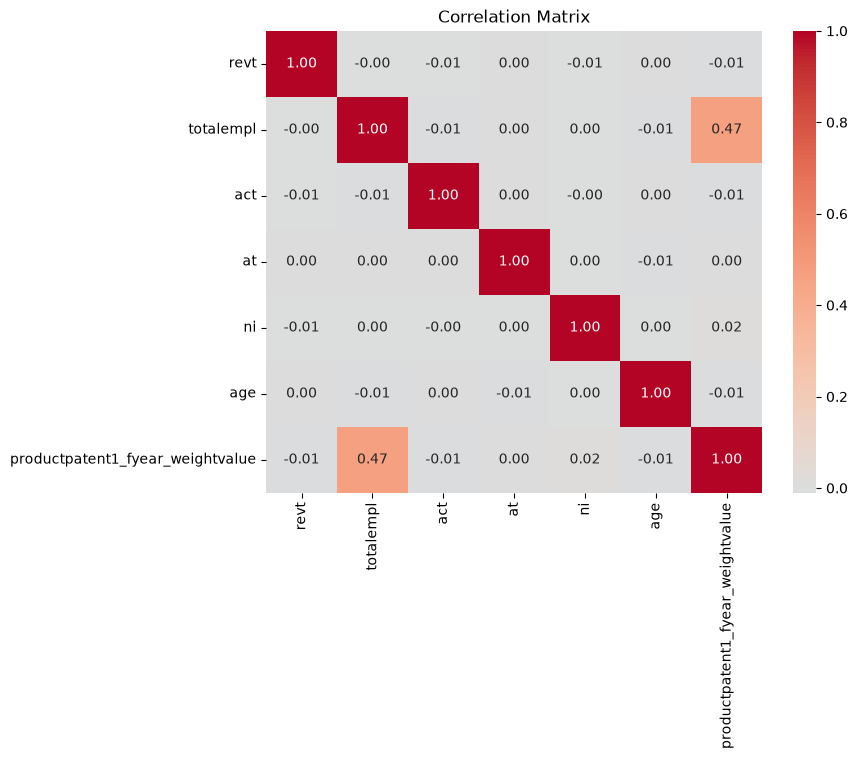

In [ ]:

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## running a correlation matrix with all numerical variables 

due to the vast amount of variables, we saved the correlation matrix to an image. 
result: the correlation matrix doesnt show any noteworthy correlation from the data, the only correlation from the whole dataset it can show is that the firm size correlates to some extent with the number of patents. 

In [ ]:
corr_full = data.select_dtypes(include="number").corr()

print(corr_full) 

                      gvkey      year    aiempl  totalempl       act  \
gvkey              1.000000 -0.019584 -0.015530  -0.080690 -0.002940   
year              -0.019584  1.000000  0.070412   0.039201 -0.003332   
aiempl            -0.015530  0.070412  1.000000   0.530727 -0.002804   
totalempl         -0.080690  0.039201  0.530727   1.000000 -0.007447   
act               -0.002940 -0.003332 -0.002804  -0.007447  1.000000   
...                     ...       ...       ...        ...       ...   
roa                0.004992  0.006264  0.001389   0.000163  0.005801   
ni_over_totalempl  0.048623 -0.007374 -0.014471  -0.041972 -0.001540   
log_totalempl     -0.166314  0.059174  0.181660   0.461059 -0.004234   
log_aiemplratio    0.187854  0.269225  0.134661  -0.186850  0.016131   
log_market_cap     0.008132  0.004694 -0.002543   0.000397  0.001070   

                         ap    apalch       aqc        at      bast  ...  \
gvkey              0.001258  0.000109  0.001521 -0.002203  

In [1]:

# plt.figure(figsize=(10,10))

# sns.heatmap(
#     corr,
#     annot=True,
#     cmap="coolwarm",
#     center=0,
#     fmt=".2f"
# )

# plt.title("Correlation Matrix")

# # plt.savefig(
# #     "correlation_matrix.png",
# #     dpi=300,              # High resolution
# #     # bbox_inches="tight"   # Removes excess whitespace
# # )


# plt.show()




In [2]:
# plt.savefig("correlation_matrix.svg") 